# Modelos de Machine Learning — Walk-Forward + SHAP

8 modelos (4 puntuales + 4 por cuantiles) sobre NVDA, MSFT y GOOGL, evaluados con **walk-forward de ventana expandible** y el **mismo motor de backtest** que `metodos_tradicionales.ipynb`.

- **Selección de variables:** VIF iterativo + ADF (set fijo de 9). SHAP NO selecciona.
- **Folds:** test = 1 año; 9 folds 2017→2025; train expandible anclado en 2011; gap de 1 día (anti-fuga).
- **Señal puntual:** compra `r̂ > θ`, liquida `r̂ < −θ`. **Señal cuantil:** compra `Q0.1 > θ`, liquida `Q0.9 < −θ`.
- **OOS agrupado** (manzana con manzana vs tradicionales) + **Sharpe por fold** (estabilidad entre regímenes).
- **SHAP** al final, solo interpretación (Objetivo 1).

Detalle en `metodología/plan_walkforward_shap.md`.

## 0. Instalación de dependencias (ejecutar una vez)

In [19]:
import sys
# tensorflow es pesado: si no vas a correr los LSTM, puedes quitarlo de la lista.
#!{sys.executable} -m pip install -q numpy pandas scikit-learn xgboost shap matplotlib statsmodels quantile-forest tensorflow

## 1. Imports y detección de paquetes disponibles

In [20]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor

np.random.seed(0)

# Los modelos opcionales se registran solo si su paquete esta disponible.
DISPONIBLES = {}
try:
    from xgboost import XGBRegressor; DISPONIBLES['xgboost'] = True
except Exception as e:
    DISPONIBLES['xgboost'] = False; print('xgboost no disponible:', e)
try:
    from quantile_forest import RandomForestQuantileRegressor; DISPONIBLES['qforest'] = True
except Exception as e:
    DISPONIBLES['qforest'] = False; print('quantile-forest no disponible:', e)
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Dense
    tf.random.set_seed(0); DISPONIBLES['tensorflow'] = True
except Exception as e:
    DISPONIBLES['tensorflow'] = False; print('tensorflow no disponible:', e)
try:
    import shap; DISPONIBLES['shap'] = True
except Exception as e:
    DISPONIBLES['shap'] = False; print('shap no disponible:', e)

print('Disponibles:', DISPONIBLES)

Disponibles: {'xgboost': True, 'qforest': True, 'tensorflow': True, 'shap': True}


## 2. Configuración (idéntica a los tradicionales donde aplica)

In [21]:
CAPITAL_INICIAL = 10_000
COSTO = 0.001          # 0.1% por operacion
DIAS_ANIO = 252
THETA = 0.002          # umbral de la senal (0.2%)
GAP = 1                # hueco train->test (el target usa shift(-1))
L_LSTM = 20            # memoria del LSTM (dias)

TICKERS = ['NVDA', 'MSFT', 'GOOGL']
DATA_DIR = Path('datos')

# Set curado por VIF + ADF (9 variables, todas estacionarias)
FEATURES = ['BB_upper_diff', 'Gold_ret', 'MACD_signal', 'Momentum_10',
            'NASDAQ_ret', 'RSI_14', 'SP500_ret', 'Volume', 'WilliamsR_14']

# Walk-forward de ventana expandible
ANIO_INICIO_OOS = 2017
ANIO_FIN_OOS = 2025
QUANTILES = [0.1, 0.5, 0.9]

## 3. Carga de datos y feature engineering

In [22]:
def cargar(ticker):
    df = pd.read_csv(DATA_DIR / f'{ticker}_dataset.csv', parse_dates=['Date'])
    df = df.set_index('Date').sort_index()
    # Transformacion de estacionariedad decidida por ADF: BB_upper -> diferencia lag-1
    df['BB_upper_diff'] = df['BB_upper'].diff()
    # La ultima fila no tiene dia siguiente real (target NaN) -> fuera
    df = df[df['Target_Retorno_1d'].notna()]
    # Warm-up: descarta filas iniciales con NaN en alguna feature curada
    df = df.dropna(subset=FEATURES)
    return df

## 4. Folds del walk-forward (ventana expandible + gap anti-fuga)

In [23]:
def generar_folds(idx):
    # Para cada anio de test, train = todo lo anterior menos GAP filas (hueco anti-fuga).
    folds = []
    for anio in range(ANIO_INICIO_OOS, ANIO_FIN_OOS + 1):
        test_pos = np.where(idx.year == anio)[0]
        if len(test_pos) == 0:
            continue
        train_pos = np.arange(0, test_pos[0])
        if GAP > 0:
            train_pos = train_pos[:-GAP]
        if len(train_pos) == 0:
            continue
        folds.append((anio, train_pos, test_pos))
    return folds

## 5. Motor de backtest (IDÉNTICO a `metodos_tradicionales.ipynb`)

In [24]:
# Mismo motor: garantiza que ML y tradicionales se midan con la misma vara.
def _maquina_estado(compra, venta):
    c = compra.to_numpy(); v = venta.to_numpy()
    pos = np.zeros(len(c), dtype=int); estado = 0
    for i in range(len(c)):
        if estado == 0 and c[i]:
            estado = 1
        elif estado == 1 and v[i]:
            estado = 0
        pos[i] = estado
    return pd.Series(pos, index=compra.index)

def backtest(pos, ret, capital=CAPITAL_INICIAL, costo=COSTO):
    pos = pos.astype(float)
    cambios = pos.diff().abs(); cambios.iloc[0] = abs(pos.iloc[0])
    r = pos * ret - costo * cambios
    r.iloc[-1] = r.iloc[-1] - costo * pos.iloc[-1]
    equity = capital * (1.0 + r).cumprod()
    return r, equity

def metricas(r, equity, pos, ret):
    n = len(r); cap_final = equity.iloc[-1]
    ret_total = cap_final / CAPITAL_INICIAL - 1.0
    ret_anual = (cap_final / CAPITAL_INICIAL) ** (DIAS_ANIO / n) - 1.0
    sigma = r.std(ddof=1)
    sharpe = np.sqrt(DIAS_ANIO) * r.mean() / sigma if sigma > 0 else np.nan
    vol = sigma * np.sqrt(DIAS_ANIO)
    max_dd = (equity / equity.cummax() - 1.0).min()
    en_mercado = pos == 1
    hit = (ret[en_mercado] > 0).mean() if en_mercado.any() else np.nan
    n_compras = int((pos.diff() > 0).sum() + (pos.iloc[0] > 0))
    return {'Retorno Total': ret_total, 'Retorno Anual': ret_anual, 'Sharpe': sharpe,
            'Volatilidad': vol, 'Max Drawdown': max_dd, 'Hit Ratio': hit,
            '% en mercado': en_mercado.mean(), 'N compras': n_compras}

# Senales tradicionales (para re-reportarlas sobre el MISMO tramo OOS)
def senal_buy_hold(df): return pd.Series(1, index=df.index)
def senal_sma(df): return (df['SMA_20'] > df['SMA_50']).astype(int)
def senal_macd(df): return (df['MACD'] > df['MACD_signal']).astype(int)
def senal_rsi(df):
    rsi = df['RSI_14']; prev = rsi.shift(1)
    compra = (prev < 30) & (rsi >= 30); venta = (prev > 70) & (rsi <= 70)
    return _maquina_estado(compra.fillna(False), venta.fillna(False))
def senal_mean_reversion(df):
    compra = df['Close'] <= df['BB_lower']; venta = df['Close'] >= df['BB_upper']
    return _maquina_estado(compra, venta)
SENALES_TRAD = {'Buy & Hold': senal_buy_hold, 'SMA Crossover': senal_sma, 'MACD': senal_macd,
                'RSI': senal_rsi, 'Mean Reversion': senal_mean_reversion}

## 6. Señales de trading desde las predicciones ML

In [25]:
def senal_puntual(pred):
    # Histeresis: compra si r_hat > theta, liquida si r_hat < -theta.
    return _maquina_estado(pred > THETA, pred < -THETA)

def senal_cuantil(q50):
    # Gatillo por la MEDIANA con histeresis (igual que el puntual): compra Q0.5 > theta, liquida Q0.5 < -theta.
    # El intervalo [Q0.1, Q0.9] NO se usa para operar: se reserva para medir incertidumbre (Objetivo 2).
    return _maquina_estado(q50 > THETA, q50 < -THETA)

## 7. Registro de modelos

Cada modelo expone `tipo` ('puntual'/'cuantil'), `escalado` (None/'standard'), `secuencial` (bool) y
`fit/predict` (o `fit_predict` para los secuenciales). El escalado por fold lo aplica el bucle.

In [26]:
# --- Puntuales ---
class MLineal:
    tipo='puntual'; escalado='standard'; secuencial=False
    def fit(self, X, y): self.m = LinearRegression().fit(X, y)
    def predict(self, X): return self.m.predict(X)

class MRandomForest:
    tipo='puntual'; escalado=None; secuencial=False
    def fit(self, X, y): self.m = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0).fit(X, y)
    def predict(self, X): return self.m.predict(X)

class MXGBoost:
    tipo='puntual'; escalado=None; secuencial=False
    def fit(self, X, y):
        self.m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, random_state=0, tree_method='hist').fit(X, y)
    def predict(self, X): return self.m.predict(X)

# --- Cuantiles (devuelven matriz n x 3: q10, q50, q90) ---
class MCuantLineal:
    tipo='cuantil'; escalado='standard'; secuencial=False
    def fit(self, X, y):
        self.ms = [QuantileRegressor(quantile=q, alpha=0.0, solver='highs').fit(X, y) for q in QUANTILES]
    def predict(self, X): return np.column_stack([m.predict(X) for m in self.ms])

class MCuantRF:
    tipo='cuantil'; escalado=None; secuencial=False
    def fit(self, X, y):
        self.m = RandomForestQuantileRegressor(n_estimators=300, n_jobs=-1, random_state=0).fit(X, y)
    def predict(self, X): return np.asarray(self.m.predict(X, quantiles=QUANTILES))

class MCuantXGB:
    # XGBoost nativo multi-cuantil (reg:quantileerror, requiere xgboost>=2.0).
    # TODO tesina: para fidelidad con el Cap. 5, sustituir por la pinball-arctan de Sluijterman (2025).
    tipo='cuantil'; escalado=None; secuencial=False
    def fit(self, X, y):
        self.m = XGBRegressor(objective='reg:quantileerror', quantile_alpha=np.array(QUANTILES),
                              n_estimators=400, max_depth=4, learning_rate=0.05,
                              tree_method='hist', random_state=0).fit(X, y)
    def predict(self, X):
        p = np.asarray(self.m.predict(X))
        return p if p.ndim == 2 else p.reshape(-1, len(QUANTILES))

In [27]:
# --- Secuenciales (LSTM): hacen su propio escalado MinMax y construccion de secuencias ---
def _make_seq(arr, L):
    if len(arr) < L:
        return np.empty((0, L, arr.shape[1]))
    return np.stack([arr[i-L+1:i+1] for i in range(L-1, len(arr))])

class MLSTM:
    tipo='puntual'; escalado=None; secuencial=True
    def fit_predict(self, Xtr, ytr, Xte):
        sc = MinMaxScaler().fit(Xtr.values)
        Xtr_s, Xte_s = sc.transform(Xtr.values), sc.transform(Xte.values)
        Xseq = _make_seq(Xtr_s, L_LSTM); yseq = ytr.values[L_LSTM-1:]
        Xcat = np.vstack([Xtr_s[-(L_LSTM-1):], Xte_s]); Xseq_te = _make_seq(Xcat, L_LSTM)
        m = Sequential([Input((L_LSTM, Xtr_s.shape[1])), LSTM(32), Dense(1)])
        m.compile(optimizer='adam', loss='mse')
        m.fit(Xseq, yseq, epochs=20, batch_size=32, verbose=0)
        return m.predict(Xseq_te, verbose=0).ravel()

def _pinball(qs):
    qs = tf.constant(qs, dtype=tf.float32)
    def loss(yt, yp):
        e = yt - yp
        return tf.reduce_mean(tf.maximum(qs * e, (qs - 1.0) * e))
    return loss

class MCuantLSTM:
    tipo='cuantil'; escalado=None; secuencial=True
    def fit_predict(self, Xtr, ytr, Xte):
        sc = MinMaxScaler().fit(Xtr.values)
        Xtr_s, Xte_s = sc.transform(Xtr.values), sc.transform(Xte.values)
        Xseq = _make_seq(Xtr_s, L_LSTM); yseq = ytr.values[L_LSTM-1:].reshape(-1, 1)
        Xcat = np.vstack([Xtr_s[-(L_LSTM-1):], Xte_s]); Xseq_te = _make_seq(Xcat, L_LSTM)
        m = Sequential([Input((L_LSTM, Xtr_s.shape[1])), LSTM(32), Dense(len(QUANTILES))])
        m.compile(optimizer='adam', loss=_pinball(QUANTILES))
        m.fit(Xseq, yseq, epochs=20, batch_size=32, verbose=0)
        return m.predict(Xseq_te, verbose=0)

In [28]:
def construir_modelos():
    M = {'Regresion Lineal': MLineal(), 'Random Forest': MRandomForest(),
         'Reg. Lineal Cuantil': MCuantLineal()}
    if DISPONIBLES['xgboost']:
        M['XGBoost'] = MXGBoost(); M['XGBoost Cuantil'] = MCuantXGB()
    if DISPONIBLES['qforest']:
        M['Random Forest Cuantil'] = MCuantRF()
    if DISPONIBLES['tensorflow']:
        M['LSTM'] = MLSTM(); M['LSTM Cuantil'] = MCuantLSTM()
    return M

MODELOS = construir_modelos()
print('Modelos a evaluar:', list(MODELOS.keys()))

Modelos a evaluar: ['Regresion Lineal', 'Random Forest', 'Reg. Lineal Cuantil', 'XGBoost', 'XGBoost Cuantil', 'Random Forest Cuantil', 'LSTM', 'LSTM Cuantil']


## 8. Ejecución del walk-forward (pesada — corre una vez)

Para cada acción y modelo se entrena/predice fold por fold y se **cachean las predicciones** a
`predicciones_oos.csv`. Las reglas de señal y el backtest se aplican en la celda 9 (barata): así,
para probar otra regla **no hay que reentrenar** (basta re-correr la celda 9).

In [29]:
def predecir_oos(modelo, X, y, folds):
    partes = []
    for anio, tr, te in folds:
        Xtr, ytr, Xte = X.iloc[tr], y.iloc[tr], X.iloc[te]
        idx_te = X.index[te]
        if modelo.secuencial:
            p = modelo.fit_predict(Xtr, ytr, Xte)
        else:
            if modelo.escalado == 'standard':
                sc = StandardScaler().fit(Xtr.values)
                a_tr, a_te = sc.transform(Xtr.values), sc.transform(Xte.values)
            else:
                a_tr, a_te = Xtr.values, Xte.values
            modelo.fit(a_tr, ytr.values); p = modelo.predict(a_te)
        p = np.asarray(p)
        if modelo.tipo == 'puntual':
            df_p = pd.DataFrame({'pred': p.ravel()}, index=idx_te)
        else:
            df_p = pd.DataFrame(p, columns=['q10', 'q50', 'q90'], index=idx_te)
        df_p['fold'] = anio
        partes.append(df_p)
    return pd.concat(partes)


# Corre el walk-forward UNA vez y cachea las predicciones a disco.
registros = []
for ticker in TICKERS:
    df = cargar(ticker)
    X, y = df[FEATURES], df['Target_Retorno_1d']
    folds = generar_folds(df.index)
    for nombre, modelo in MODELOS.items():
        pred = predecir_oos(modelo, X, y, folds)
        out = pd.DataFrame({'Fecha': pred.index})
        out['Accion'] = ticker; out['Metodo'] = nombre; out['Familia'] = modelo.tipo
        out['fold'] = pred['fold'].values
        out['ret'] = y.loc[pred.index].values          # retorno realizado (para el backtest)
        if modelo.tipo == 'puntual':
            out['pred'] = pred['pred'].values
        else:
            out['q10'] = pred['q10'].values
            out['q50'] = pred['q50'].values
            out['q90'] = pred['q90'].values
        registros.append(out)
    print(f'{ticker}: predicciones listas ({len(folds)} folds, {len(MODELOS)} modelos)')

pred_long = pd.concat(registros, ignore_index=True)
pred_long.to_csv('predicciones_oos.csv', index=False, encoding='utf-8')
print('Guardado: predicciones_oos.csv (', len(pred_long), 'filas ).')

NVDA: predicciones listas (9 folds, 8 modelos)
MSFT: predicciones listas (9 folds, 8 modelos)
GOOGL: predicciones listas (9 folds, 8 modelos)
Guardado: predicciones_oos.csv ( 54240 filas ).


## 9. Evaluación de reglas → resultados (barata, re-ejecutable sin reentrenar)

Aplica las reglas de señal a las predicciones cacheadas y corre el motor. **Para probar otra regla:**
cambia `senal_cuantil`/`senal_puntual` (celda 6) y re-corre SOLO esta celda — no hace falta reentrenar.

In [30]:
def evaluar(pred_long):
    filas, por_fold, curvas = [], [], {}
    for (ticker, nombre), g in pred_long.groupby(['Accion', 'Metodo'], sort=False):
        g = g.sort_values('Fecha')
        idx = pd.DatetimeIndex(pd.to_datetime(g['Fecha'].values))
        familia = g['Familia'].iloc[0]
        r_oos = pd.Series(g['ret'].values, index=idx)
        if familia == 'puntual':
            punto = pd.Series(g['pred'].values, index=idx)
            pos = senal_puntual(punto)
        else:
            punto = pd.Series(g['q50'].values, index=idx)
            pos = senal_cuantil(punto)
        r, equity = backtest(pos, r_oos)
        m = metricas(r, equity, pos, r_oos)
        err = r_oos.values - punto.values
        m['MSE'] = float(np.mean(err ** 2))
        m['RSE'] = float(np.sqrt(np.sum(err ** 2) / (len(err) - len(FEATURES))))
        m['Hit Ratio Pred'] = float(np.mean(np.sign(punto.values) == np.sign(r_oos.values)))
        m.update({'Accion': ticker, 'Metodo': nombre, 'Familia': familia})
        filas.append(m); curvas[(ticker, nombre)] = equity
        folds_g = pd.Series(g['fold'].values, index=idx)
        for anio in sorted(folds_g.unique()):
            rr = r.loc[folds_g.index[folds_g == anio]]
            sg = rr.std(ddof=1)
            por_fold.append({'Accion': ticker, 'Metodo': nombre, 'Fold': int(anio),
                             'Sharpe': np.sqrt(DIAS_ANIO) * rr.mean() / sg if sg > 0 else np.nan})
    return pd.DataFrame(filas), pd.DataFrame(por_fold), curvas

resultados_raw, pf, curvas_ml = evaluar(pred_long)
cols = ['Familia', 'MSE', 'RSE', 'Hit Ratio Pred', 'Retorno Total', 'Retorno Anual', 'Sharpe',
        'Volatilidad', 'Max Drawdown', 'Hit Ratio', '% en mercado', 'N compras']
resultados_ml = resultados_raw.set_index(['Accion', 'Metodo'])[cols]
resultados_ml.to_csv('resultados_ml.csv', encoding='utf-8')
pf.to_csv('resultados_ml_por_fold.csv', index=False, encoding='utf-8')
print('Guardado: resultados_ml.csv, resultados_ml_por_fold.csv')
resultados_ml.round(4)

Guardado: resultados_ml.csv, resultados_ml_por_fold.csv


Familia     MSE     RSE  Hit Ratio Pred  \
Accion Metodo                                                           
NVDA   Regresion Lineal       puntual  0.0010  0.0318          0.5230   
       Random Forest          puntual  0.0012  0.0345          0.5013   
       Reg. Lineal Cuantil    cuantil  0.0010  0.0318          0.5243   
       XGBoost                puntual  0.0012  0.0348          0.5062   
       XGBoost Cuantil        cuantil  0.0011  0.0334          0.5115   
       Random Forest Cuantil  cuantil  0.0012  0.0349          0.5000   
       LSTM                   puntual  0.0011  0.0335          0.5044   
       LSTM Cuantil           cuantil  0.0011  0.0332          0.5062   
MSFT   Regresion Lineal       puntual  0.0003  0.0172          0.5221   
       Random Forest          puntual  0.0003  0.0186          0.5066   
       Reg. Lineal Cuantil    cuantil  0.0003  0.0171          0.5230   
       XGBoost                puntual  0.0004  0.0189          0.5119   
       XGBoost Cuantil        cuantil  0.0003  0.0178          0.5332   
       Random Forest Cuantil  cuantil  0.0004  0.0193          0.5168   
       LSTM                   puntual  0.0003  0.0182          0.4876   
       LSTM Cuantil           cuantil  0.0004  0.0187          0.5027   
GOOGL  Regresion Lineal       puntual  0.0003  0.0187          0.5097   
       Random Forest          puntual  0.0004  0.0194          0.5128   
       Reg. Lineal Cuantil    cuantil  0.0003  0.0187          0.5243   
       XGBoost                puntual  0.0004  0.0200          0.5235   
       XGBoost Cuantil        cuantil  0.0004  0.0192          0.5274   
       Random Forest Cuantil  cuantil  0.0004  0.0193          0.5137   
       LSTM                   puntual  0.0004  0.0198          0.5133   
       LSTM Cuantil           cuantil  0.0004  0.0204          0.4965   

                              Retorno Total  Retorno Anual  Sharpe  \
Accion Metodo                                                        
NVDA   Regresion Lineal             35.6445         0.4941  1.1480   
       Random Forest                11.3995         0.3241  0.9140   
       Reg. Lineal Cuantil          41.0266         0.5172  1.1935   
       XGBoost                      10.7395         0.3160  0.9016   
       XGBoost Cuantil               6.4893         0.2517  0.7691   
       Random Forest Cuantil         8.5839         0.2866  0.8502   
       LSTM                          6.9765         0.2605  0.8351   
       LSTM Cuantil                 12.4622         0.3363  1.0177   
MSFT   Regresion Lineal              4.0497         0.1979  0.9044   
       Random Forest                 1.4265         0.1039  0.5568   
       Reg. Lineal Cuantil           7.0676         0.2621  1.1016   
       XGBoost                       2.6797         0.1564  0.7779   
       XGBoost Cuantil               4.2248         0.2025  0.9085   
       Random Forest Cuantil         2.3377         0.1438  0.7069   
       LSTM                          1.8463         0.1237  0.8673   
       LSTM Cuantil                  3.7731         0.1904  0.8919   
GOOGL  Regresion Lineal              1.9689         0.1290  0.5909   
       Random Forest                 1.7776         0.1207  0.6108   
       Reg. Lineal Cuantil           4.2389         0.2028  0.8071   
       XGBoost                       3.9820         0.1961  0.9065   
       XGBoost Cuantil               6.3028         0.2482  1.0045   
       Random Forest Cuantil         2.0280         0.1315  0.6361   
       LSTM                          2.7366         0.1583  0.9093   
       LSTM Cuantil                  0.5660         0.0513  0.3298   

                              Volatilidad  Max Drawdown  Hit Ratio  \
Accion Metodo                                                        
NVDA   Regresion Lineal            0.4299       -0.5688     0.5419   
       Random Forest               0.3899       -0.5512     0.5378   
       Reg. Lineal Cuantil    

## 10. Tradicionales sobre el MISMO tramo OOS (manzana con manzana)

In [31]:
filas_trad, curvas_trad = [], {}
for ticker in TICKERS:
    df = cargar(ticker)
    folds = generar_folds(df.index)
    oos_idx = df.index[np.concatenate([te for _, _, te in folds])]
    ret = df['Target_Retorno_1d']
    for nombre, fn in SENALES_TRAD.items():
        pos = fn(df).loc[oos_idx]          # senal con warm-up de toda la historia, evaluada solo en OOS
        r_oos = ret.loc[oos_idx]
        r, equity = backtest(pos, r_oos)
        m = metricas(r, equity, pos, r_oos)
        m.update({'Accion': ticker, 'Metodo': nombre, 'Familia': 'tradicional'})
        filas_trad.append(m)
        curvas_trad[(ticker, nombre)] = equity

resultados_trad_oos = pd.DataFrame(filas_trad).set_index(['Accion', 'Metodo'])
resultados_trad_oos.to_csv('resultados_tradicionales_oos.csv', encoding='utf-8')

# Tabla combinada ordenada por Sharpe (la metrica principal)
comp = pd.concat([
    resultados_ml.reset_index()[['Accion', 'Metodo', 'Familia', 'Sharpe', 'Retorno Total', 'Max Drawdown']],
    resultados_trad_oos.reset_index()[['Accion', 'Metodo', 'Familia', 'Sharpe', 'Retorno Total', 'Max Drawdown']],
]).set_index(['Accion', 'Metodo'])
comp.sort_values(['Accion', 'Sharpe'], ascending=[True, False]).round(3)

Familia  Sharpe  Retorno Total  Max Drawdown
Accion Metodo                                                                 
GOOGL  XGBoost Cuantil            cuantil   1.005          6.303        -0.260
       Buy & Hold             tradicional   0.921          6.812        -0.443
       LSTM                       puntual   0.909          2.737        -0.281
       XGBoost                    puntual   0.907          3.982        -0.269
       SMA Crossover          tradicional   0.873          3.426        -0.390
       Reg. Lineal Cuantil        cuantil   0.807          4.239        -0.443
       Mean Reversion         tradicional   0.692          2.011        -0.274
       Random Forest Cuantil      cuantil   0.636          2.028        -0.377
       Random Forest              puntual   0.611          1.778        -0.299
       Regresion Lineal           puntual   0.591          1.969        -0.349
       MACD                   tradicional   0.443          0.873        -0.445
       LSTM Cuantil               cuantil   0.330          0.566        -0.547
       RSI                    tradicional   0.277          0.370        -0.406
MSFT   Reg. Lineal Cuantil        cuantil   1.102          7.068        -0.256
       Buy & Hold             tradicional   1.021          7.641        -0.371
       XGBoost Cuantil            cuantil   0.909          4.225        -0.259
       Regresion Lineal           puntual   0.904          4.050        -0.251
       LSTM Cuantil               cuantil   0.892          3.773        -0.280
       LSTM                       puntual   0.867          1.846        -0.211
       XGBoost                    puntual   0.778          2.680        -0.267
       Random Forest Cuantil      cuantil   0.707          2.338        -0.339
       SMA Crossover          tradicional   0.704          2.008        -0.441
       Mean Reversion         tradicional   0.684          2.077        -0.354
       Random Forest              puntual   0.557          1.426        -0.365
       RSI                    tradicional   0.501          1.027        -0.265
       MACD                   tradicional   0.171          0.141        -0.404
NVDA   Buy & Hold             tradicional   1.209         73.504        -0.663
       Reg. Lineal Cuantil        cuantil   1.194         41.027        -0.611
       Regresion Lineal           puntual   1.148         35.645        -0.569
       LSTM Cuantil               cuantil   1.018         12.462        -0.376
       Mean Reversion         tradicional   0.976         11.862        -0.486
       RSI                    tradicional   0.973          7.599        -0.475
       SMA Crossover          tradicional   0.972         13.497        -0.638
       Random Forest              puntual   0.914         11.399        -0.551
       XGBoost                    puntual   0.902         10.740        -0.462
       Random Forest Cuantil      cuantil   0.850          8.584        -0.606
       LSTM                       puntual   0.835          6.976        -0.529
       XGBoost Cuantil            cuantil   0.769          6.489        -0.582
       MACD                   tradicional   0.762          5.303        -0.531

## 11. Curvas de capital OOS (escala log): ML vs Buy & Hold

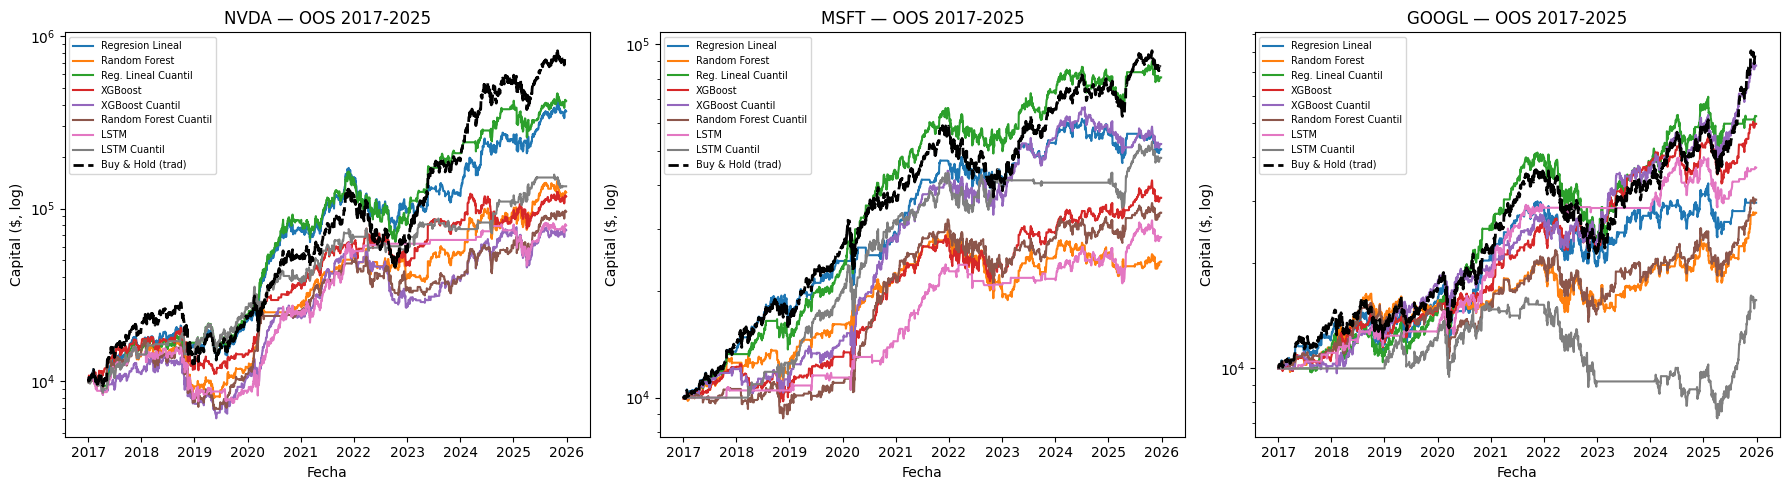

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ticker in zip(axes, TICKERS):
    for nombre in MODELOS:
        ax.plot(curvas_ml[(ticker, nombre)], label=nombre)
    ax.plot(curvas_trad[(ticker, 'Buy & Hold')], 'k--', lw=2, label='Buy & Hold (trad)')
    ax.set_yscale('log'); ax.set_title(f'{ticker} — OOS {ANIO_INICIO_OOS}-{ANIO_FIN_OOS}')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Capital ($, log)'); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

## 12. Estabilidad entre regímenes (Sharpe por fold)

In [33]:
# 'pf' (Sharpe por fold) ya fue calculado por evaluar() en la celda 9
tabla_estab = pf.pivot_table(index=['Accion', 'Metodo'], columns='Fold', values='Sharpe').round(2)
display(tabla_estab)
print('\nSharpe entre folds (media +/- desviacion):')
pf.groupby(['Accion', 'Metodo'])['Sharpe'].agg(['mean', 'std']).round(3)

Fold                          2017  2018  2019  2020  2021  2022  2023  2024  \
Accion Metodo                                                                  
GOOGL  LSTM                   1.75  0.64  0.65  1.46  2.12  0.01   NaN  1.43   
       LSTM Cuantil            NaN   NaN  1.00  0.66  0.39 -1.12 -1.00  0.23   
       Random Forest          1.43  0.92  0.55  0.09  1.87 -0.68  1.14  0.87   
       Random Forest Cuantil  1.57  0.76  0.78  0.18  1.88 -0.69  1.22  1.06   
       Reg. Lineal Cuantil    1.34  0.08  1.21  1.73  2.30 -1.15  1.74  1.46   
       Regresion Lineal       1.51  0.08  1.21  0.96  1.82 -0.74  1.22  0.72   
       XGBoost                0.64  0.74  1.24  0.55  2.46 -0.30  2.77  0.70   
       XGBoost Cuantil        0.20  1.04  1.89  0.40  1.89 -0.27  1.88  1.30   
MSFT   LSTM                   0.73   NaN  0.87  1.27  2.78 -0.61  0.55  0.88   
       LSTM Cuantil            NaN  1.20  2.76  1.26  1.66  0.02  0.09   NaN   
       Random Forest          1.83  0.10  1.82  1.05  1.82 -0.84  1.21  0.16   
       Random Forest Cuantil  0.68 -0.39  1.04  2.04  2.23 -0.65  1.15  0.45   
       Reg. Lineal Cuantil    2.33  0.58  2.51  1.88  2.15 -0.42  1.46  0.51   
       Regresion Lineal       2.34  1.21  2.10  0.62  3.39 -0.10  1.25  0.38   
       XGBoost                2.02 -0.56  1.44  1.59  1.71 -0.32  1.27  0.93   
       XGBoost Cuantil        1.84 -0.11  1.53  1.94  2.50 -0.23  1.92  0.33   
NVDA   LSTM                   1.26 -0.93  0.30  2.23  2.07  1.06  1.55  0.76   
       LSTM Cuantil           1.20  0.13  1.78  0.97  1.70 -0.61  1.01  1.48   
       Random Forest          1.16 -0.66  0.98  2.37  2.57 -0.48  1.06  1.45   
       Random Forest Cuantil  1.20 -1.01  1.11  2.30  2.66 -0.61  0.76  1.25   
       Reg. Lineal Cuantil    1.39  0.48  1.20  2.67  1.53 -0.77  2.65  1.98   
       Regresion Lineal       1.55  0.26  1.09  2.63  1.81 -0.66  0.74  1.96   
       XGBoost                1.65 -0.34  0.62  2.53  1.74 -0.36  1.65  0.48   
       XGBoost Cuantil        0.46 -0.53  1.13  2.10  2.38 -1.27  1.55  1.73   

Fold                          2025  
Accion Metodo                       
GOOGL  LSTM                  -0.01  
       LSTM Cuantil           1.75  
       Random Forest          1.06  
       Random Forest Cuantil  1.10  
       Reg. Lineal Cuantil   -0.04  
       Regresion Lineal      -0.12  
       XGBoost                0.74  
       XGBoost Cuantil        1.58  
MSFT   LSTM                   0.69  
       LSTM Cuantil           0.79  
       Random Forest         -0.16  
       Random Forest Cuantil  0.55  
       Reg. Lineal Cuantil    0.19  
       Regresion Lineal      -0.34  
       XGBoost                0.56  
       XGBoost Cuantil       -0.27  
NVDA   LSTM                   0.37  
       LSTM Cuantil           0.75  
       Random Forest          0.85  
       Random Forest Cuantil  1.25  
       Reg. Lineal Cuantil    0.39  
       Regresion Lineal       1.07  
       XGBoost                0.82  
       XGBoost Cuantil        0.25


Sharpe entre folds (media +/- desviacion):


mean    std
Accion Metodo                             
GOOGL  LSTM                   1.005  0.801
       LSTM Cuantil           0.272  1.035
       Random Forest          0.805  0.750
       Random Forest Cuantil  0.873  0.761
       Reg. Lineal Cuantil    0.965  1.101
       Regresion Lineal       0.740  0.840
       XGBoost                1.060  0.972
       XGBoost Cuantil        1.100  0.816
MSFT   LSTM                   0.895  0.939
       LSTM Cuantil           1.113  0.949
       Random Forest          0.777  0.992
       Random Forest Cuantil  0.790  0.968
       Reg. Lineal Cuantil    1.243  1.056
       Regresion Lineal       1.206  1.222
       XGBoost                0.962  0.901
       XGBoost Cuantil        1.053  1.104
NVDA   LSTM                   0.964  0.980
       LSTM Cuantil           0.934  0.770
       Random Forest          1.032  1.089
       Random Forest Cuantil  0.990  1.190
       Reg. Lineal Cuantil    1.280  1.118
       Regresion Lineal       1.163  0.980
       XGBoost                0.977  0.991
       XGBoost Cuantil        0.867  1.232

## 13. Calidad de los intervalos — incertidumbre (Objetivo 2)

Los cuantiles `[Q0.1, Q0.9]` ya no operan; aquí se evalúan como tales: la **cobertura empírica** debería
rondar **0.80** (un intervalo 10-90 bien calibrado contiene el 80% de los retornos), el **ancho medio**
mide cuánta incertidumbre reporta el modelo, y los **cruces** (Q0.9 < Q0.1) delatan mala calibración.

In [34]:
cuant = pred_long[pred_long['Familia'] == 'cuantil'].copy()
cuant['dentro'] = (cuant['ret'] >= cuant['q10']) & (cuant['ret'] <= cuant['q90'])
cuant['ancho'] = cuant['q90'] - cuant['q10']
cobertura = cuant.groupby(['Accion', 'Metodo']).agg(
    cobertura_80=('dentro', 'mean'),
    ancho_medio=('ancho', 'mean'),
    pct_cruces=('ancho', lambda w: float((w < 0).mean())),
).round(3)
cobertura.to_csv('cobertura.csv', encoding='utf-8')
print('Guardado: cobertura.csv. Cobertura ideal ~0.80. pct_cruces > 0 => quantile crossing (mala calibracion).')
cobertura

Guardado: cobertura.csv. Cobertura ideal ~0.80. pct_cruces > 0 => quantile crossing (mala calibracion).


cobertura_80  ancho_medio  pct_cruces
Accion Metodo                                                      
GOOGL  LSTM Cuantil                  0.692        0.035       0.000
       Random Forest Cuantil         0.773        0.044       0.000
       Reg. Lineal Cuantil           0.671        0.029       0.000
       XGBoost Cuantil               0.664        0.031       0.000
MSFT   LSTM Cuantil                  0.731        0.034       0.000
       Random Forest Cuantil         0.801        0.042       0.000
       Reg. Lineal Cuantil           0.712        0.029       0.000
       XGBoost Cuantil               0.671        0.029       0.003
NVDA   LSTM Cuantil                  0.685        0.063       0.002
       Random Forest Cuantil         0.810        0.085       0.000
       Reg. Lineal Cuantil           0.669        0.053       0.000
       XGBoost Cuantil               0.646        0.054       0.002

## 14. SHAP — interpretación (Objetivo 1)

SHAP es **solo interpretativo** (la selección la hicieron VIF+ADF). Se entrena el modelo sobre la serie
completa y se explica para obtener la relevancia global de cada variable. La Figura 9 de la tesina es el
beeswarm de XGBoost; aquí se genera por acción y se añade la relevancia por año (¿cambia según el
periodo?).

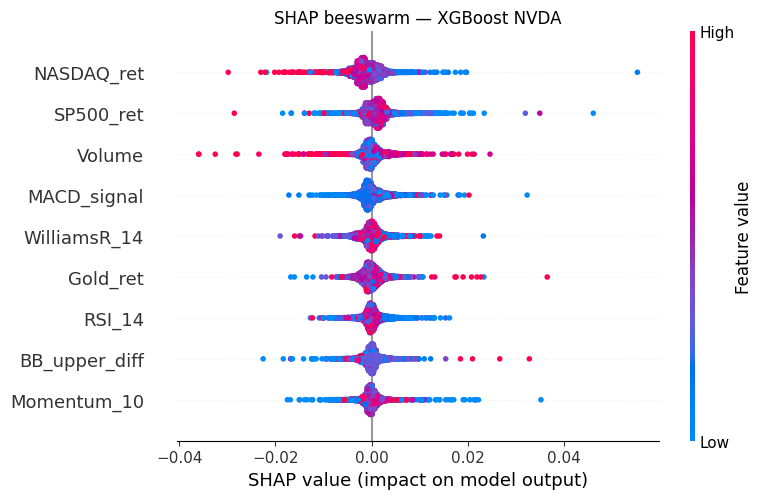

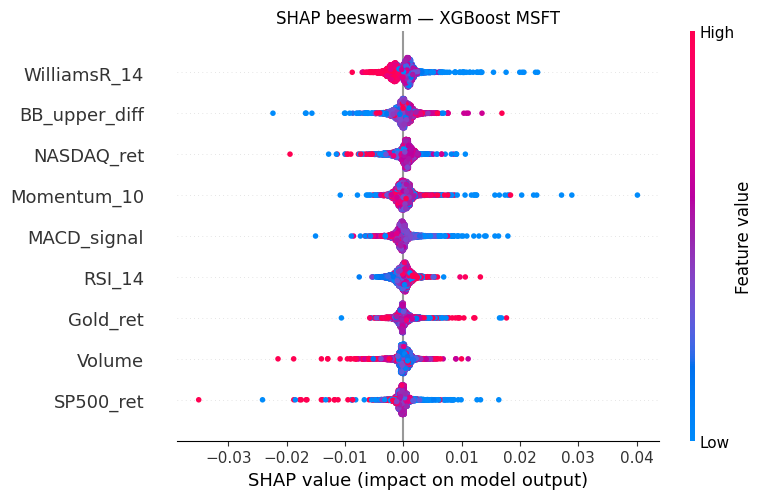

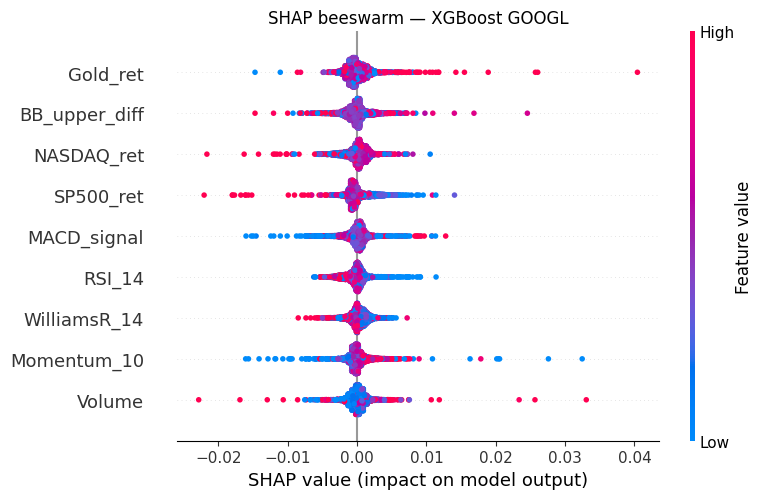

In [35]:
if DISPONIBLES['shap'] and DISPONIBLES['xgboost']:
    for ticker in TICKERS:
        df = cargar(ticker); X, y = df[FEATURES], df['Target_Retorno_1d']
        m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, random_state=0, tree_method='hist').fit(X.values, y.values)
        sv = shap.TreeExplainer(m).shap_values(X.values)
        shap.summary_plot(sv, X, feature_names=FEATURES, show=False)
        plt.title(f'SHAP beeswarm — XGBoost {ticker}'); plt.tight_layout(); plt.show()
else:
    print('SHAP o XGBoost no disponibles; se omite.')

In [36]:
# ¿Cambia la relevancia segun el periodo? mean|SHAP| relativo por anio (XGBoost, NVDA)
if DISPONIBLES['shap'] and DISPONIBLES['xgboost']:
    df = cargar('NVDA'); X, y = df[FEATURES], df['Target_Retorno_1d']
    m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                     random_state=0, tree_method='hist').fit(X.values, y.values)
    sv = shap.TreeExplainer(m).shap_values(X.values)
    sv_abs = pd.DataFrame(np.abs(sv), columns=FEATURES, index=X.index)
    por_anio = sv_abs.groupby(sv_abs.index.year).mean()
    rel = por_anio.div(por_anio.sum(axis=1), axis=0)   # relevancia relativa (suma 1 por anio)
    display(rel.round(3))
else:
    print('SHAP o XGBoost no disponibles; se omite.')

,BB_upper_diff,Gold_ret,MACD_signal,Momentum_10,NASDAQ_ret,RSI_14,SP500_ret,Volume,WilliamsR_14
Date,,,,,,,,,
2011,0.038,0.112,0.073,0.093,0.139,0.147,0.141,0.165,0.092
2012,0.041,0.120,0.070,0.069,0.169,0.143,0.147,0.118,0.123
2013,0.045,0.136,0.104,0.065,0.153,0.126,0.111,0.125,0.135
2014,0.039,0.120,0.117,0.063,0.167,0.143,0.144,0.099,0.108
2015,0.045,0.105,0.132,0.068,0.163,0.127,0.151,0.099,0.111
2016,0.062,0.107,0.164,0.075,0.156,0.110,0.116,0.106,0.104
2017,0.074,0.111,0.117,0.077,0.107,0.135,0.081,0.177,0.121
2018,0.052,0.088,0.104,0.121,0.144,0.117,0.124,0.136,0.114
2019,0.067,0.104,0.111,0.092,0.136,0.152,0.102,0.132,0.105


## Pendientes tras correr

1. Sanity check de resultados (¿el ML supera al Buy & Hold en Sharpe OOS? ¿en qué acción?).
2. ¿Sustituir XGBoost cuantil por la pinball-arctan de Sluijterman (2025) para fidelidad con el Cap. 5?
3. Regenerar la Figura 9 con el set de 9 y reescribir Tabla 2 / §5.4.
4. LSTM con `DeepExplainer` es opcional (caro); por ahora SHAP cubre XGBoost/RF/lineales.
5. Mejora: extraer el motor a `backtest_engine.py` e importarlo en ambos notebooks.